In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!du -sh  /content/drive/MyDrive/flood/s1_VV_buchanan_dam_2018-01-01T003447_GeoTIFF.tif

23M	/content/drive/MyDrive/flood/s1_VV_buchanan_dam_2018-01-01T003447_GeoTIFF.tif


In [ ]:
# INSTALLING REQUIRED LIBRARIES
!pip install -U pyproj -q
!pip install -U utm -q
!pip install -U google-colab -q
!pip install -U tornado -q
!pip install geemap -q
!pip install wxee
!pip install rioxarray pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.9/443.9 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires tornado==6.4.2, but you have tornado 6.5.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 4.7 MB/s eta 0:00:00


In [ ]:
import rasterio
import xarray as xr
import numpy as np

# Open the GeoTIFF
with rasterio.open("/content/drive/MyDrive/flood/s1_VV_buchanan_dam_2018-01-01T003447_GeoTIFF.tif") as src:
    data = src.read(1)  # first band
    transform = src.transform
    crs = src.crs

    # Reproject to EPSG:4326 if necessary
    if crs.to_epsg() != 4326:
        from rasterio.warp import calculate_default_transform, reproject, Resampling
        transform, width, height = calculate_default_transform(
            crs, "EPSG:4326", src.width, src.height, *src.bounds
        )
        kwargs = src.meta.copy()
        kwargs.update({
            "crs": "EPSG:4326",
            "transform": transform,
            "width": width,
            "height": height
        })

        data_reproj = np.empty((height, width), dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=data_reproj,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs="EPSG:4326",
            resampling=Resampling.nearest
        )
        data = data_reproj

# Build coordinates
lon = np.arange(data.shape[1]) * transform.a + transform.c
lat = np.arange(data.shape[0]) * transform.e + transform.f

# Convert to xarray dataset
ds = xr.Dataset(
    {"variable": (["lat", "lon"], data)},
    coords={"lon": lon, "lat": lat},
)

# Save as NetCDF
ds.to_netcdf("output.nc")

In [ ]:
!ls

drive  output.nc  sample_data


In [ ]:
ds = xr.open_dataset('/content/output.nc')
ds

<xarray.Dataset> Size: 232MB
Dimensions:   (lat: 5009, lon: 5791)
Coordinates:
  * lon       (lon) float64 46kB -98.67 -98.67 -98.67 ... -98.15 -98.15 -98.15
  * lat       (lat) float64 40kB 30.98 30.98 30.98 30.98 ... 30.53 30.53 30.53
Data variables:
    variable  (lat, lon) float64 232MB ...

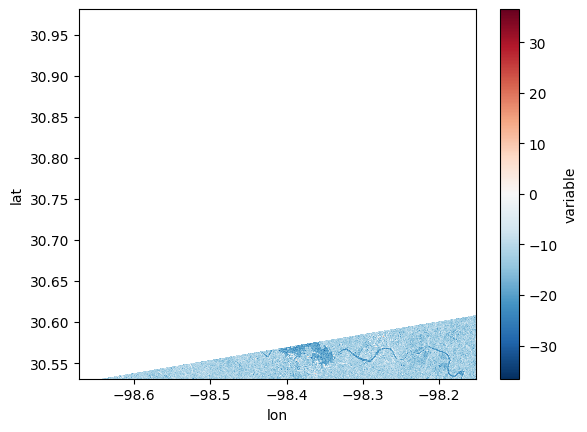

In [ ]:
ds.variable.plot()

In [ ]:
!ls /content/drive/MyDrive/flood

s1_VV_buchanan_dam_2018-01-01T003447_GeoTIFF.tif
s1_VV_buchanan_dam_2018-01-01T003512_GeoTIFF.tif
s1_VV_buchanan_dam_2018-01-25T003446_GeoTIFF.tif
s1_VV_buchanan_dam_2018-01-25T003511_GeoTIFF.tif
s1_VV_buchanan_dam_2018-02-06T003446_GeoTIFF.tif
s1_VV_buchanan_dam_2018-02-06T003511_GeoTIFF.tif
s1_VV_buchanan_dam_2018-02-18T003446_GeoTIFF.tif
s1_VV_buchanan_dam_2018-02-18T003511_GeoTIFF.tif
s1_VV_buchanan_dam_2018-03-02T003446_GeoTIFF.tif
s1_VV_buchanan_dam_2018-03-02T003511_GeoTIFF.tif
s1_VV_buchanan_dam_2018-03-14T003446_GeoTIFF.tif
s1_VV_buchanan_dam_2018-03-14T003511_GeoTIFF.tif
s1_VV_buchanan_dam_2018-03-26T003446_GeoTIFF.tif
s1_VV_buchanan_dam_2018-03-26T003511_GeoTIFF.tif
s1_VV_buchanan_dam_2018-04-07T003446_GeoTIFF.tif
s1_VV_buchanan_dam_2018-04-07T003511_GeoTIFF.tif
s1_VV_buchanan_dam_2018-05-01T003447_GeoTIFF.tif
s1_VV_buchanan_dam_2018-05-01T003512_GeoTIFF.tif
s1_VV_buchanan_dam_2018-05-13T003448_GeoTIFF.tif
s1_VV_buchanan_dam_2018-05-13T003513_GeoTIFF.tif
s1_VV_buchanan_dam_2

In [ ]:
import os
import rasterio
import xarray as xr
import numpy as np

# Directory containing the GeoTIFF files
input_directory = "/content/drive/MyDrive/flood/"
output_directory = "/content/drive/MyDrive/flood/"

# List all files in the directory
tif_files = [f for f in os.listdir(input_directory) if f.endswith(".tif")]

# Loop through each GeoTIFF file
for tif_file in tif_files:
    # Construct full file path
    tif_path = os.path.join(input_directory, tif_file)

    try:
        # Open the GeoTIFF
        with rasterio.open(tif_path) as src:
            data = src.read(1)  # first band
            transform = src.transform
            crs = src.crs

            # Reproject to EPSG:4326 if necessary
            if crs.to_epsg() != 4326:
                from rasterio.warp import calculate_default_transform, reproject, Resampling
                transform, width, height = calculate_default_transform(
                    crs, "EPSG:4326", src.width, src.height, *src.bounds
                )
                kwargs = src.meta.copy()
                kwargs.update({
                    "crs": "EPSG:4326",
                    "transform": transform,
                    "width": width,
                    "height": height
                })

                data_reproj = np.empty((height, width), dtype=np.float32)
                reproject(
                    source=rasterio.band(src, 1),
                    destination=data_reproj,
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs="EPSG:4326",
                    resampling=Resampling.nearest
                )
                data = data_reproj

        # Build coordinates
        lon = np.arange(data.shape[1]) * transform.a + transform.c
        lat = np.arange(data.shape[0]) * transform.e + transform.f

        # Convert to xarray dataset
        ds = xr.Dataset(
            {"variable": (["lat", "lon"], data)},
            coords={"lon": lon, "lat": lat},
        )

        # Construct output file name with .nc extension
        nc_file = os.path.splitext(tif_file)[0] + ".nc"
        nc_path = os.path.join(output_directory, nc_file)

        # Save as NetCDF
        ds.to_netcdf(nc_path)
        print(f"Processed and saved: {nc_path}")

    except rasterio.errors.RasterioIOError as e:
        print(f"Error reading {tif_file}: {e}")
        continue  # Skip to the next file if there's an error

Processed and saved: /content/drive/MyDrive/flood/s1_VV_buchanan_dam_2018-01-01T003447_GeoTIFF.nc
Processed and saved: /content/drive/MyDrive/flood/s1_VV_buchanan_dam_2018-01-01T003512_GeoTIFF.nc
Processed and saved: /content/drive/MyDrive/flood/s1_VV_buchanan_dam_2018-01-25T003446_GeoTIFF.nc
Processed and saved: /content/drive/MyDrive/flood/s1_VV_buchanan_dam_2018-02-06T003446_GeoTIFF.nc
Processed and saved: /content/drive/MyDrive/flood/s1_VV_buchanan_dam_2018-01-25T003511_GeoTIFF.nc
Processed and saved: /content/drive/MyDrive/flood/s1_VV_buchanan_dam_2018-02-06T003511_GeoTIFF.nc
Processed and saved: /content/drive/MyDrive/flood/s1_VV_buchanan_dam_2018-02-18T003446_GeoTIFF.nc
Processed and saved: /content/drive/MyDrive/flood/s1_VV_buchanan_dam_2018-02-18T003511_GeoTIFF.nc
Processed and saved: /content/drive/MyDrive/flood/s1_VV_buchanan_dam_2018-03-02T003511_GeoTIFF.nc
Processed and saved: /content/drive/MyDrive/flood/s1_VV_buchanan_dam_2018-03-02T003446_GeoTIFF.nc
Processed and saved:

In [ ]:
!ls /content/MyDrive/

ls: cannot access '/content/MyDrive/': No such file or directory
